In [1]:
print("hi")

hi


In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

In [3]:
from typing import TypedDict
from dotenv import load_dotenv

In [4]:
import os
load_dotenv(override=True)

True

In [5]:
def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        max_tokens= 1000
    )

In [6]:
llm= get_groq_llm()

In [7]:
class LLMState(TypedDict):
    question: str
    answer: str

In [8]:
def chat_llm(state: LLMState):

    question= state['question']

    ##prompt:
    prompt= f'Answer the following Question {question}'

    answer= llm.invoke(prompt).content
    
    state['answer']= answer

    return state


    


In [9]:
graph= StateGraph(LLMState)

## add nodes

graph.add_node('chat_llm',chat_llm)

In [10]:
## add edges

graph.add_edge(START,'chat_llm')
graph.add_edge('chat_llm', END)

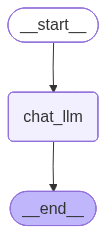

In [11]:
workflow= graph.compile()

workflow

In [12]:
intial_state= {'question':'How far is the moon from earth'}

final_state= workflow.invoke(intial_state)

print(final_state)

{'question': 'How far is the moon from earth', 'answer': 'The Moon orbits the Earth at an average distance of **about\u202f384\u202f400\u202fkilometers** (≈\u202f238\u202f855\u202fmiles).  \n\n- **Closest approach (perigee):** ~363\u202f300\u202fkm (≈\u202f225\u202f600\u202fmi)  \n- **Farthest distance (apogee):** ~405\u202f500\u202fkm (≈\u202f251\u202f900\u202fmi)  \n\nThese values vary slightly because the Moon’s orbit is elliptical.'}


In [13]:
print(final_state['answer'])

The Moon orbits the Earth at an average distance of **about 384 400 kilometers** (≈ 238 855 miles).  

- **Closest approach (perigee):** ~363 300 km (≈ 225 600 mi)  
- **Farthest distance (apogee):** ~405 500 km (≈ 251 900 mi)  

These values vary slightly because the Moon’s orbit is elliptical.


In [14]:
intial_state= {'question':'okay great but how far from Sun?'}

final_state= workflow.invoke(intial_state)

In [15]:
print(final_state)

{'question': 'okay great but how far from Sun?', 'answer': 'I’m happy to help!\u202fIt sounds like you’d like to know the distance from the Sun for a particular object (e.g., a planet, asteroid, spacecraft, etc.). Could you let me know which body you have in mind? Once I know that, I can give you its average distance from the Sun (usually expressed in kilometers, miles, or astronomical units).'}


In [16]:
print(final_state['answer'])


I’m happy to help! It sounds like you’d like to know the distance from the Sun for a particular object (e.g., a planet, asteroid, spacecraft, etc.). Could you let me know which body you have in mind? Once I know that, I can give you its average distance from the Sun (usually expressed in kilometers, miles, or astronomical units).


## Call to llm:
## Stateless Calls: It does not have any previous message history



##

User_query_no1: hsxbshbxh
llm: hsxbhjsxhbv

user_q2: follow up question
llm: proper answe

## sending all prev, info to llm